# Revenue Drop Diagnosis: Why Did February Revenue Fall -13.5%?

Recap from the previous notebook: paid revenue fell from 39,119.5 EUR (January) to 33,827.0 EUR (February), a -5,292.5 EUR (-13.5%) drop, with no single-day cliff.

This notebook tests concrete, falsifiable hypotheses for the cause, in two passes:

- Quick pass - cheap checks for the "usual suspects" that, if true, would need no further digging. Most of these turn out to have a small effect.
- Deep dive - the two signals that actually explain the drop, followed by a check for whether they are really two separate causes or the same cause showing up twice.

All queries are defined in [**sql/03_revenue_drop_hypotheses.sql**](../sql/03_revenue_drop_hypotheses.sql) and loaded here by name via **src/db.py**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.db import get_connection, load_query  # noqa: E402

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PAID_SOCIAL_COLOR = "#d62728"
OTHER_COLOR = "#4c72b0"

SQL_FILE = "03_revenue_drop_hypotheses.sql"
con = get_connection()

## Quick pass: ruling out the usual suspects

### H1 - Calendar effect: February simply has fewer days

January has 31 days, February has 28 - 3 fewer selling days (-9.7%). If daily order volume had stayed the same, that alone would shrink monthly order count.

In [2]:
display(con.execute(load_query(SQL_FILE, "calendar_effect")).fetchdf())

,order_month,paid_orders,days_in_period,orders_per_day
0,2026-01-01,1790,31,57.74
1,2026-02-01,1739,28,62.11


Verdict: ruled out. Orders *per day* actually rose from 57.7 to 62.1 (+7.6%), which almost fully offset the shorter month. Applying January's daily order rate to 28 days would give ~1,616 orders vs the 1,739 actually observed in February - i.e. February needed a *higher* daily pace just to land where it did. The calendar explains at most a couple of percentage points, not the -13.5% headline number.

### H2 - Refunds ate into revenue

Did more customers ask for their money back in February?

In [3]:
display(con.execute(load_query(SQL_FILE, "refund_rate")).fetchdf())

,order_month,total_orders,refunded_orders,refund_rate_pct,refunded_amount_eur,revenue_eur
0,2026-01-01,1831,41,2.24,850.0,39119.5
1,2026-02-01,1787,48,2.69,932.5,33827.0


Verdict: ruled out. The refund rate ticked up slightly (2.24% -> 2.69% of orders), but that's an extra ~82 EUR of refunded value - about 1.5% of the total drop. Not the story.

### H3 - Regional demand shifted

Maybe a handful of countries pulled back sharply.

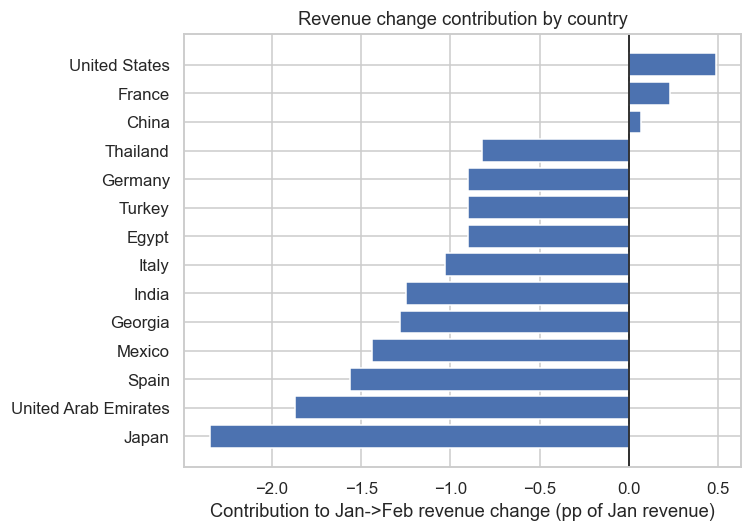

In [5]:
country_mix = con.execute(load_query(SQL_FILE, "country_mix")).fetchdf()

fig, ax = plt.subplots(figsize=(7, 5))
country_mix_sorted = country_mix.sort_values("contribution_to_change_pp")
ax.barh(country_mix_sorted["order_country"], country_mix_sorted["contribution_to_change_pp"], color=OTHER_COLOR)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Contribution to Jan->Feb revenue change (pp of Jan revenue)")
ax.set_title("Revenue change contribution by country")
plt.tight_layout()
plt.show()

Verdict: ruled out. Almost every country contributed a small negative amount (-0.8 to -2.4 pp), and 3 countries (US, France, China) actually grew. There's no single country driving the drop - this looks like a broad, shallow effect rather than a regional problem.

### H4 - Platform mix (iOS / Android / web)

In [6]:
display(con.execute(load_query(SQL_FILE, "platform_mix")).fetchdf())

,order_platform,jan_revenue,feb_revenue,contribution_to_change_pp
0,web,9007.0,7037.0,-5.04
1,ios,19011.5,17099.5,-4.89
2,android,11101.0,9690.5,-3.61


Verdict: ruled out. All three platforms lost between -3.6 and -5.0 pp - again a broad, evenly spread effect, not a platform-specific bug or outage.

### H5 - Fewer repeat purchases

In [7]:
display(con.execute(load_query(SQL_FILE, "repeat_purchase_share")).fetchdf())

,order_month,order_type,paid_orders,users,revenue_eur
0,2026-01-01,first_purchase,1660,1660,36474.0
1,2026-01-01,repeat_purchase,130,130,2645.5
2,2026-02-01,first_purchase,1610,1610,31189.0
3,2026-02-01,repeat_purchase,129,129,2638.0


Verdict: ruled out. Repeat-purchase revenue barely moved (2,645.5 -> 2,638.0 EUR, one fewer order). Whatever is happening, it isn't about existing customers buying less often.

---

## Deep dive: the two real signals

None of the "usual suspects" above move the needle. Let's decompose revenue directly: revenue = paid orders x average order value (AOV).

### H6 - Orders vs. average order value (AOV)

Order count fell only slightly (1,790 -> 1,739, -2.8%), but if AOV also fell, its effect on revenue is multiplied by the (larger) February order count. The query below splits the total revenue change into a volume effect (order count change x January's AOV) and an AOV effect (February's order count x AOV change).

,jan_revenue,feb_revenue,jan_orders,feb_orders,jan_aov,feb_aov,revenue_change_eur,volume_effect_eur,aov_effect_eur
0,39119.5,33827.0,1790,1739,21.854469,19.451984,-5292.5,-1114.58,-4177.92


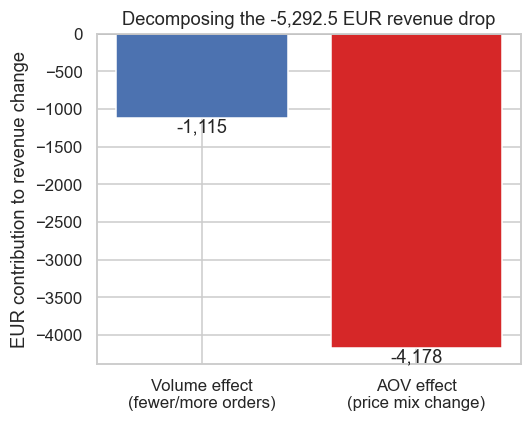

In [8]:
decomposition = con.execute(load_query(SQL_FILE, "volume_aov_decomposition")).fetchdf()
display(decomposition)

fig, ax = plt.subplots(figsize=(5, 4))
effects = decomposition[["volume_effect_eur", "aov_effect_eur"]].iloc[0]
ax.bar(["Volume effect\n(fewer/more orders)", "AOV effect\n(price mix change)"], effects, color=[OTHER_COLOR, PAID_SOCIAL_COLOR])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("EUR contribution to revenue change")
ax.set_title("Decomposing the -5,292.5 EUR revenue drop")
for i, v in enumerate(effects):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom" if v > 0 else "top")
plt.tight_layout()
plt.show()

Verdict: confirmed driver. The AOV effect (-4,177.9 EUR) is roughly 4x the volume effect (-1,114.6 EUR). AOV fell from 21.85 to 19.45 EUR (-11%) - that's the main thing to explain. Two more specific hypotheses follow: did the *acquisition channel mix* change, and did the *tariff/package mix* change?

### H7 - A specific acquisition channel underperformed

,acquisition_channel,jan_revenue,feb_revenue,jan_orders,feb_orders,revenue_change_pct,contribution_to_change_pp
0,paid_social,17215.5,5418.5,605,193,-68.53,-30.16
1,referral,2829.0,3772.0,154,207,33.33,2.41
2,organic,9649.5,11320.0,542,618,17.31,4.27
3,affiliate,1933.0,3695.5,129,283,91.18,4.51
4,paid_search,7492.5,9621.0,360,438,28.41,5.44


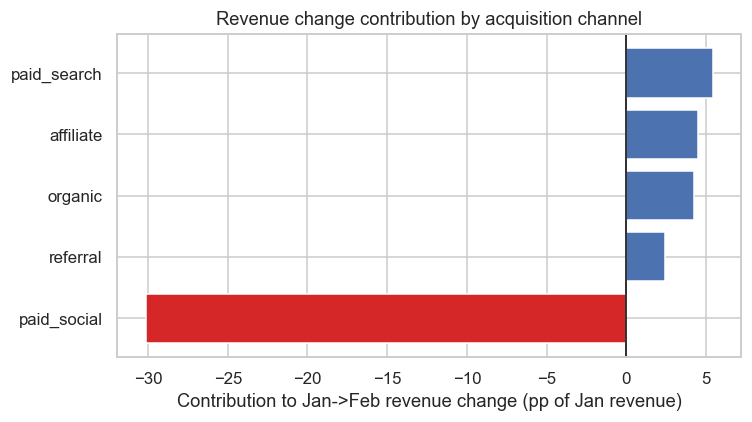

In [9]:
channel = con.execute(load_query(SQL_FILE, "acquisition_channel")).fetchdf()
display(channel)

fig, ax = plt.subplots(figsize=(7, 4))
order = channel.sort_values("contribution_to_change_pp")
colors = [PAID_SOCIAL_COLOR if c == "paid_social" else OTHER_COLOR for c in order["acquisition_channel"]]
ax.barh(order["acquisition_channel"], order["contribution_to_change_pp"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Contribution to Jan->Feb revenue change (pp of Jan revenue)")
ax.set_title("Revenue change contribution by acquisition channel")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_channel_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

Verdict: confirmed driver. **paid_social** revenue collapsed from 17,215.5 to 5,418.5 EUR (-68.5%), contributing -30.2 pp relative to January's total revenue - by far the single largest factor found so far. Every other channel actually *grew* in February (referral, organic, affiliate, paid_search are all positive).

### H8 - Tariff/package mix shifted toward cheaper plans

,packet_size_name,jan_revenue,feb_revenue,jan_orders,feb_orders,orders_change_pct,contribution_to_change_pp
0,Unlimited 30 days,7205.0,5225.0,131,95,-27.48,-5.06
1,50 GB,6027.0,4214.0,123,86,-30.08,-4.63
2,Unlimited 15 days,5005.0,3780.0,143,108,-24.48,-3.13
3,20 GB,3683.0,2900.0,127,100,-21.26,-2.00
4,Unlimited 7 days,3938.0,3586.0,179,163,-8.94,-0.90
5,5 GB,5174.0,5265.0,398,405,1.76,0.23
6,1 GB,913.5,1071.0,203,238,17.24,0.40
7,10 GB,5320.0,5491.0,280,289,3.21,0.44
8,3 GB,1854.0,2295.0,206,255,23.79,1.13


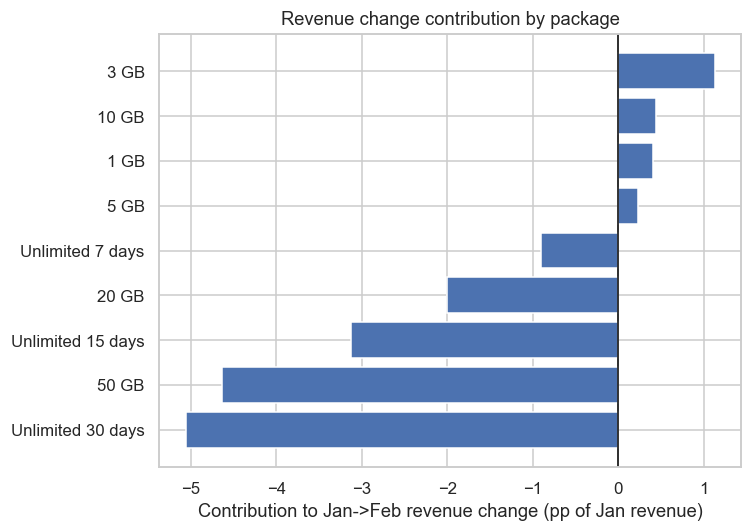

In [11]:
tariff = con.execute(load_query(SQL_FILE, "tariff_mix")).fetchdf()
display(tariff)

fig, ax = plt.subplots(figsize=(7, 5))
order = tariff.sort_values("contribution_to_change_pp")
ax.barh(order["packet_size_name"], order["contribution_to_change_pp"], color=OTHER_COLOR)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Contribution to Jan->Feb revenue change (pp of Jan revenue)")
ax.set_title("Revenue change contribution by package")
plt.tight_layout()
plt.show()

Looks like a confirmed driver at first glance: every "expensive" package (Unlimited 30/15/7 days, 50 GB, 20 GB) lost 9-30% of its orders, while every "cheap" package (1-10 GB) grew. This lines up neatly with the AOV drop from H6.

But before accepting this at face value: is the tariff shift an *independent* cause, or is it just a side effect of the **paid_social** collapse from H7? **paid_social** might simply have been the channel that happened to sell the most expensive plans - in which case losing that channel's volume would mechanically look like "a shift away from expensive tariffs" without any real change in what any individual customer segment prefers. That's exactly the kind of confound worth checking explicitly rather than assuming away.

### H9 - Stress test: is the tariff-mix effect actually the **paid_social** effect in disguise?

In [12]:
interaction = con.execute(load_query(SQL_FILE, "channel_tariff_interaction")).fetchdf()
display(interaction)
print(f"\n{(interaction['acquisition_channel'] == 'paid_social').sum()} of the top {len(interaction)} "
      "negative channel x package combinations belong to paid_social, across every package size it sells "
      "(not just the expensive ones) - consistent with a channel-wide volume drop, not a tariff-specific one.")

,acquisition_channel,packet_size_name,jan_revenue,feb_revenue,jan_orders,feb_orders,contribution_to_change_pp
0,paid_social,Unlimited 30 days,4015.0,1045.0,73,19,-7.59
1,paid_social,50 GB,3577.0,1225.0,73,25,-6.01
2,paid_social,Unlimited 15 days,2625.0,910.0,75,26,-4.38
3,paid_social,10 GB,2280.0,741.0,120,39,-3.93
4,paid_social,20 GB,2001.0,812.0,69,28,-3.04
5,paid_social,Unlimited 7 days,1298.0,198.0,59,9,-2.81
6,paid_social,5 GB,1001.0,312.0,77,24,-1.76
7,affiliate,Unlimited 30 days,385.0,165.0,7,3,-0.56
8,paid_social,3 GB,306.0,144.0,34,16,-0.41
9,organic,Unlimited 30 days,1540.0,1430.0,28,26,-0.28



9 of the top 15 negative channel x package combinations belong to paid_social, across every package size it sells (not just the expensive ones) - consistent with a channel-wide volume drop, not a tariff-specific one.


In [13]:
jan_expensive_share = con.execute(
    """
    SELECT
        acquisition_channel,
        COUNT(*) FILTER (WHERE order_status = 'paid' AND order_month = DATE '2026-01-01') AS jan_orders,
        COUNT(*) FILTER (
            WHERE order_status = 'paid' AND order_month = DATE '2026-01-01'
            AND packet_size_name IN ('Unlimited 30 days', 'Unlimited 15 days', 'Unlimited 7 days', '50 GB', '20 GB')
        ) AS jan_expensive_orders
    FROM base_orders
    GROUP BY acquisition_channel
    ORDER BY jan_orders DESC
    """
).fetchdf()
jan_expensive_share["expensive_share_pct"] = (
    jan_expensive_share["jan_expensive_orders"] / jan_expensive_share["jan_orders"] * 100
).round(1)
print("Share of January orders that were 'expensive' packages, by channel:")
display(jan_expensive_share)

Share of January orders that were 'expensive' packages, by channel:


,acquisition_channel,jan_orders,jan_expensive_orders,expensive_share_pct
0,paid_social,605,349,57.7
1,organic,542,146,26.9
2,paid_search,360,136,37.8
3,referral,154,48,31.2
4,affiliate,129,24,18.6


Confirmed: **paid_social** bought "expensive" packages 57.7% of the time in January, roughly double every other channel (18.6-37.8%). So **paid_social** is not just any channel - it's the channel most concentrated in expensive plans. If it collapses, it will *automatically* look like an "expensive tariff decline" in the aggregate, even if no other customer changed their behavior at all.

Let's test that directly by removing **paid_social** and re-running both the AOV comparison and the tariff-mix query.

,channel_group,order_month,paid_orders,revenue_eur,aov_eur
0,all_other_channels,2026-01-01,1185,21904.0,18.48
1,all_other_channels,2026-02-01,1546,28408.5,18.38
2,paid_social,2026-01-01,605,17215.5,28.46
3,paid_social,2026-02-01,193,5418.5,28.08


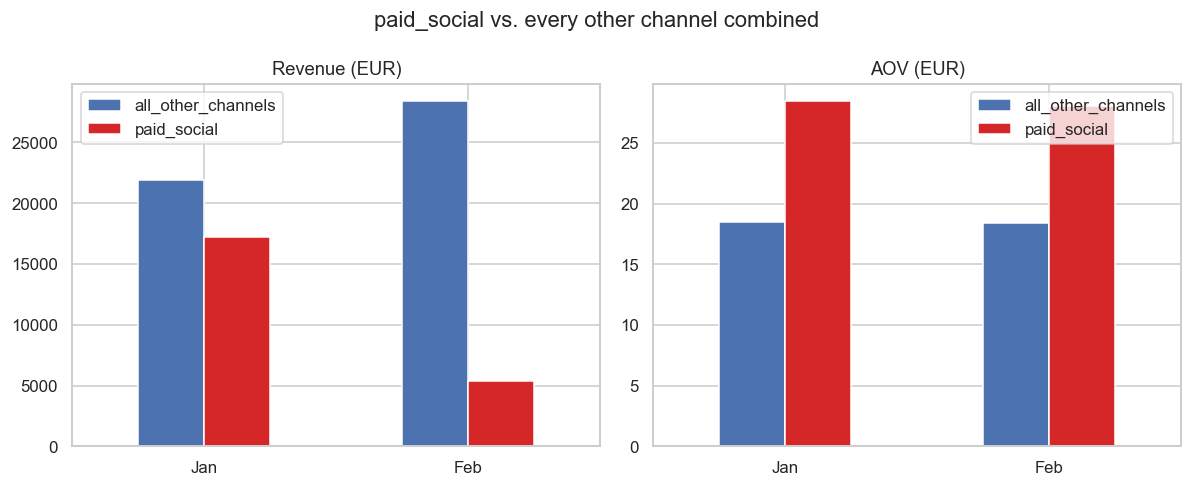

In [15]:
isolation = con.execute(load_query(SQL_FILE, "paid_social_isolation")).fetchdf()
display(isolation)

group_colors = {"paid_social": PAID_SOCIAL_COLOR, "all_other_channels": OTHER_COLOR}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, title in zip(axes, ["revenue_eur", "aov_eur"], ["Revenue (EUR)", "AOV (EUR)"]):
    pivot = isolation.pivot(index="order_month", columns="channel_group", values=metric)
    pivot.plot(kind="bar", ax=ax, color=[group_colors[col] for col in pivot.columns])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels(["Jan", "Feb"], rotation=0)
    ax.legend(title=None)
plt.suptitle("paid_social vs. every other channel combined")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_paid_social_isolation.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
tariff_excl = con.execute(load_query(SQL_FILE, "tariff_mix_excluding_paid_social")).fetchdf()
display(tariff_excl)

,packet_size_name,jan_revenue,feb_revenue,jan_orders,feb_orders,orders_change_pct
0,1 GB,801.0,1039.5,178,231,29.78
1,10 GB,3040.0,4750.0,160,250,56.25
2,20 GB,1682.0,2088.0,58,72,24.14
3,3 GB,1548.0,2151.0,172,239,38.95
4,5 GB,4173.0,4953.0,321,381,18.69
5,50 GB,2450.0,2989.0,50,61,22.00
6,Unlimited 15 days,2380.0,2870.0,68,82,20.59
7,Unlimited 30 days,3190.0,4180.0,58,76,31.03
8,Unlimited 7 days,2640.0,3388.0,120,154,28.33


Verdict: the AOV/tariff-mix effect is a downstream symptom of **paid_social**, not an independent cause.

- Excluding **paid_social**, AOV is essentially flat (18.48 -> 18.38 EUR) and every single package type grew 18-56% in orders - the opposite of what H8 seemed to show for the business as a whole.
- Excluding **paid_social**, revenue actually *grew* from 21,904.0 to 28,408.5 EUR (+29.7%). The rest of the business had a good February.
- Inside **paid_social** itself, AOV also barely moved (28.46 -> 28.08 EUR) - so even that channel's own customers didn't change what they buy. It only lost volume (605 -> 193 orders, -68.1%).

This means one root cause explains almost the entire revenue drop: **paid_social** lost roughly two-thirds of its order volume, and because it was both a large channel (44% of January revenue) and skewed toward the most expensive packages, its collapse mechanically dragged down the blended AOV and made it look like a market-wide shift away from expensive tariffs. There wasn't one.

The next notebook checks *why* **paid_social** lost volume: did fewer people register through that channel (a marketing/spend/top-of-funnel problem), or did the same number of people register but convert to a paid order less often (a product/onboarding/quality problem)?

Next: [**02_cohort_conversion_analysis.ipynb**](02_cohort_conversion_analysis.ipynb)